# Feature Engineering and Data Preparation

This notebook transforms the cleaned credit risk dataset into a machine-learning-ready format.

The workflow includes:

- Missing value treatment
- Categorical feature encoding
- Risk feature engineering
- Feature scaling
- Model-ready dataset creation

In [3]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

# Load Cleaned Dataset

Load the cleaned credit risk dataset prepared in Notebook 01.

In [4]:
# Load cleaned dataset

credit = pd.read_csv(
    "/Users/Mandy/Desktop/GithubProjects/credit-risk-prediction/data/credit_risk_cleaned.csv"
)

# Display dataset preview
credit.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


In [5]:
# Check dataset shape

credit.shape

(31521, 12)

# Missing Value Treatment

Handle missing values before feature engineering and machine learning preparation.

Numerical missing values are imputed using median values to reduce sensitivity to outliers.

In [6]:
# Check missing values

credit.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length                0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3026
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

# Interest Rate Imputation

Impute missing interest rate values using the median interest rate.

Median imputation is robust to extreme observations and is commonly used in structured machine learning workflows.

In [7]:
# Compute median interest rate

credit["loan_int_rate"].median()

10.99

In [9]:
# Fill missing interest rates with median value

credit["loan_int_rate"] = (
    credit["loan_int_rate"]
    .fillna(10.99)
)

# Check remaining missing values

credit.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

# Missing Value Treatment Summary

Missing interest rate values were imputed using the median interest rate (10.99%).

Median imputation was selected because it is less sensitive to extreme values than mean imputation and is commonly used in structured machine learning workflows.

# Categorical Feature Inspection

Inspect categorical variables before encoding them into numerical representations for machine learning.

In [10]:
# Display unique values for categorical features

categorical_features = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

for col in categorical_features:
    print("\n")
    print(col)
    print(credit[col].unique())



person_home_ownership
['OWN' 'MORTGAGE' 'RENT' 'OTHER']


loan_intent
['EDUCATION' 'MEDICAL' 'VENTURE' 'PERSONAL' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']


loan_grade
['B' 'C' 'A' 'D' 'E' 'F' 'G']


cb_person_default_on_file
['N' 'Y']


# Ordinal and Binary Encoding

Encode ordinal and binary categorical variables into numerical representations.

Loan grades possess a natural ordering, while previous default history is represented as a binary indicator.

In [11]:
# Encode loan grade

grade_mapping = {
    "A": 0,
    "B": 1,
    "C": 2,
    "D": 3,
    "E": 4,
    "F": 5,
    "G": 6
}

credit["loan_grade_encoded"] = (
    credit["loan_grade"]
    .map(grade_mapping)
)

# Encode prior default history

credit["default_history_encoded"] = (
    credit["cb_person_default_on_file"]
    .map({
        "N": 0,
        "Y": 1
    })
)

# Preview encoded variables

credit[
    [
        "loan_grade",
        "loan_grade_encoded",
        "cb_person_default_on_file",
        "default_history_encoded"
    ]
].head()

,loan_grade,loan_grade_encoded,cb_person_default_on_file,default_history_encoded
0,B,1,N,0
1,C,2,N,0
2,C,2,N,0
3,C,2,Y,1
4,A,0,N,0


# Ordinal Encoding Summary

Loan grade was encoded according to its natural credit risk ordering from A (lowest risk) to G (highest risk).

Previous default history was converted into a binary indicator variable where:

- 0 = No prior default
- 1 = Prior default

These transformations preserve important risk information while making the variables suitable for machine learning algorithms.

# One-Hot Encoding

Convert nominal categorical variables into machine-readable binary indicator variables.

One-hot encoding avoids introducing artificial ordering relationships between categories.

In [12]:
# One-hot encode categorical variables

credit = pd.get_dummies(
    credit,
    columns=[
        "person_home_ownership",
        "loan_intent"
    ],
    drop_first=True
)

# Check new dataset shape

credit.shape

(31521, 20)

# Borrower Affordability Feature

Create an affordability feature by comparing borrower income to requested loan amount.

Higher values generally indicate stronger repayment capacity and lower default risk.

In [13]:
# Create affordability feature

credit["income_to_loan_ratio"] = (
    credit["person_income"]
    / credit["loan_amnt"]
)

# Preview feature

credit[
    [
        "person_income",
        "loan_amnt",
        "income_to_loan_ratio"
    ]
].head()

,person_income,loan_amnt,income_to_loan_ratio
0,9600,1000,9.600000
1,9600,5500,1.745455
2,65500,35000,1.871429
3,54400,35000,1.554286
4,9900,2500,3.960000


# Credit History Maturity Feature

Measure how long a borrower has maintained credit relative to their age.

Higher values may indicate a more established credit profile.

In [15]:
# Create credit history maturity feature

credit["credit_history_ratio"] = (
    credit["cb_person_cred_hist_length"]
    / credit["person_age"]
)

# Preview feature

credit[
    [
        "person_age",
        "cb_person_cred_hist_length",
        "credit_history_ratio"
    ]
].head()

,person_age,cb_person_cred_hist_length,credit_history_ratio
0,21,2,0.095238
1,25,3,0.120000
2,23,2,0.086957
3,24,4,0.166667
4,21,2,0.095238


# Employment Stability Feature

Create a feature measuring employment experience relative to borrower age.

Longer employment histories may indicate greater financial stability.

In [16]:
# Create employment stability feature

credit["employment_stability"] = (
    credit["person_emp_length"]
    / credit["person_age"]
)

# Preview feature

credit[
    [
        "person_age",
        "person_emp_length",
        "employment_stability"
    ]
].head()

,person_age,person_emp_length,employment_stability
0,21,5.0,0.238095
1,25,1.0,0.040000
2,23,4.0,0.173913
3,24,8.0,0.333333
4,21,2.0,0.095238


# Interest Burden Feature

Create a feature measuring interest cost relative to borrower income.

Higher values may indicate greater repayment burden.

In [17]:
# Create interest burden feature

credit["interest_burden"] = (
    credit["loan_int_rate"]
    / credit["person_income"]
)

# Preview feature

credit[
    [
        "loan_int_rate",
        "person_income",
        "interest_burden"
    ]
].head()

,loan_int_rate,person_income,interest_burden
0,11.14,9600,0.001160
1,12.87,9600,0.001341
2,15.23,65500,0.000233
3,14.27,54400,0.000262
4,7.14,9900,0.000721


# Engineered Feature Summary

Several borrower-level risk indicators were created:

- Income-to-Loan Ratio
- Credit History Ratio
- Employment Stability
- Interest Burden

These features combine multiple raw variables into more meaningful representations of borrower affordability, financial stability, and creditworthiness.

Feature engineering allows machine learning models to learn borrower risk patterns that may not be immediately visible from raw variables alone.

# Feature Correlation Analysis

Evaluate relationships between engineered features and loan default outcomes.

Correlation analysis provides an initial indication of which variables may contain useful predictive information.

In [18]:
# Select engineered numerical features

feature_cols = [
    "loan_status",
    "income_to_loan_ratio",
    "credit_history_ratio",
    "employment_stability",
    "interest_burden",
    "loan_grade_encoded",
    "default_history_encoded",
    "loan_percent_income"
]

# Compute correlations

feature_correlations = (
    credit[feature_cols]
    .corr()
)

feature_correlations["loan_status"].sort_values(
    ascending=False
)

loan_status                1.000000
interest_burden            0.386510
loan_percent_income        0.380092
loan_grade_encoded         0.377294
default_history_encoded    0.181292
credit_history_ratio      -0.018218
employment_stability      -0.086347
income_to_loan_ratio      -0.130666
Name: loan_status, dtype: float64

# Feature Correlation Findings

Several engineered features exhibited meaningful relationships with loan default outcomes.

The strongest positive correlations with default risk were:

- Interest Burden (0.387)
- Loan Percent Income (0.380)
- Loan Grade Encoded (0.377)

These variables suggest that borrowers facing higher repayment burdens and poorer credit quality are substantially more likely to default.

Among engineered borrower-level features, Income-to-Loan Ratio and Employment Stability demonstrated negative correlations with default risk, indicating that stronger financial capacity and more stable employment histories are associated with improved repayment performance.

Overall, the results suggest that feature engineering successfully captured important borrower risk characteristics beyond the raw input variables.

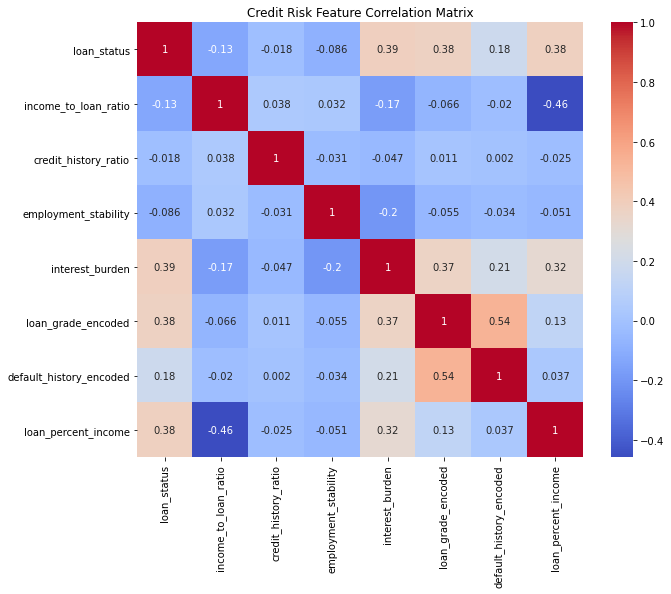

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    feature_correlations,
    annot=True,
    cmap="coolwarm"
)

plt.title("Credit Risk Feature Correlation Matrix")

plt.show()

# Feature Engineering Conclusions

Several borrower-level risk indicators were successfully engineered and evaluated.

Correlation analysis revealed that the strongest predictors of loan default were:

- Interest Burden
- Loan Percent Income
- Loan Grade

These variables showed moderate positive relationships with default risk, suggesting that repayment burden and borrower credit quality are important determinants of future loan performance.

Among engineered features, Income-to-Loan Ratio demonstrated the strongest negative relationship with default risk, indicating that borrowers with greater financial capacity relative to loan size are less likely to default.

Overall, feature engineering successfully transformed raw borrower information into more informative risk indicators, providing a stronger foundation for predictive modeling.

In [20]:
# Save engineered dataset

credit.to_csv(
    "/Users/Mandy/Desktop/GithubProjects/credit-risk-prediction/data/credit_risk_engineered.csv",
    index=False
)

print("Feature engineered dataset saved successfully.")

Feature engineered dataset saved successfully.
